# Markov-Switching GARCH для моделирования волатильности в кризисные периоды

Активы: S&P 500 (COVID-19) и Bitcoin (крипто-крахи: 2018, COVID-март-2020, Terra/Luna май-2022, FTX ноябрь-2022).

По каждому активу берём максимум доступной дневной истории отдельно

## Структура ноутбука (будет заполняться)

0. Setup
1. Загрузка данных
2. EDA: графики цен и доходностей, описательная статистика, тест Харке-Бера
3. Стационарность: ADF, KPSS
4. Кластеризация волатильности: ACF/PACF квадратов доходностей
5. Тест на ARCH-эффекты (LM/Engle test)
6. Базовые модели: ARCH, GARCH, подбор порядка по AIC/BIC
7. GJR-GARCH с t-распределением Стьюдента
8. Марковская цепь: игрушечный пример
9. Markov-Switching GARCH: построение модели
10. Вероятности режимов (фильтрованные / сглаженные)
11. Сравнение моделей (AIC/BIC/log-likelihood)
12. VaR и тест Купика
13. Повтор шагов 2-12 для Bitcoin
14. Итоговое сравнение двух кейсов
15. Экспорт финальных графиков и таблиц


## 0. Setup

In [26]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_lm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from arch import arch_model

%matplotlib inline
plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)


## 1. Загрузка данных: S&P 500 и Bitcoin

Качаем каждый актив отдельно, чтобы не обрезать более длинный ряд (S&P 500) по дате начала более короткого (Bitcoin). При повторном запуске данные читаются из локального CSV в папке `data/`

In [27]:
def load_or_download(ticker, start, path):
    if os.path.exists(path):
        s = pd.read_csv(path, index_col=0, parse_dates=True).iloc[:, 0]
        print(f'{ticker}: загружено из кэша {path}')
    else:
        s = yf.download(ticker, start=start, auto_adjust=False)['Close'].dropna()
        s.to_csv(path)
        print(f'{ticker}: скачано с Yahoo Finance и сохранено в {path}')
    return s


sp500_prices = load_or_download('^GSPC', '1990-01-01', os.path.join(DATA_DIR, 'sp500_prices.csv'))
btc_prices   = load_or_download('BTC-USD', '2010-01-01', os.path.join(DATA_DIR, 'btc_prices.csv'))

print()
print(f'S&P 500: {sp500_prices.index[0].date()} - {sp500_prices.index[-1].date()}, {len(sp500_prices)} наблюдений')
print(f'Bitcoin: {btc_prices.index[0].date()} - {btc_prices.index[-1].date()}, {len(btc_prices)} наблюдений')


^GSPC: загружено из кэша data/sp500_prices.csv
BTC-USD: загружено из кэша data/btc_prices.csv

S&P 500: 1990-01-02 - 2026-09-09, 9239 наблюдений
Bitcoin: 2014-09-17 - 2026-09-10, 4377 наблюдений


## 2. EDA: графики цен и доходностей, описательная статистика, тест Харке-Бера

Сначала считаем логарифмические доходности по обоим активам (в процентах, чтобы параметры
GARCH дальше были не микроскопическими). Дальше вся работа идёт с ними, не с ценами.

In [28]:
sp500_returns = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
btc_returns   = np.log(btc_prices / btc_prices.shift(1)).dropna()

print(f'S&P 500 доходности: {len(sp500_returns)} наблюдений')
print(f'Bitcoin доходности:  {len(btc_returns)} наблюдений')

S&P 500 доходности: 9238 наблюдений
Bitcoin доходности:  4376 наблюдений


### 2.1 Графики цен и доходностей

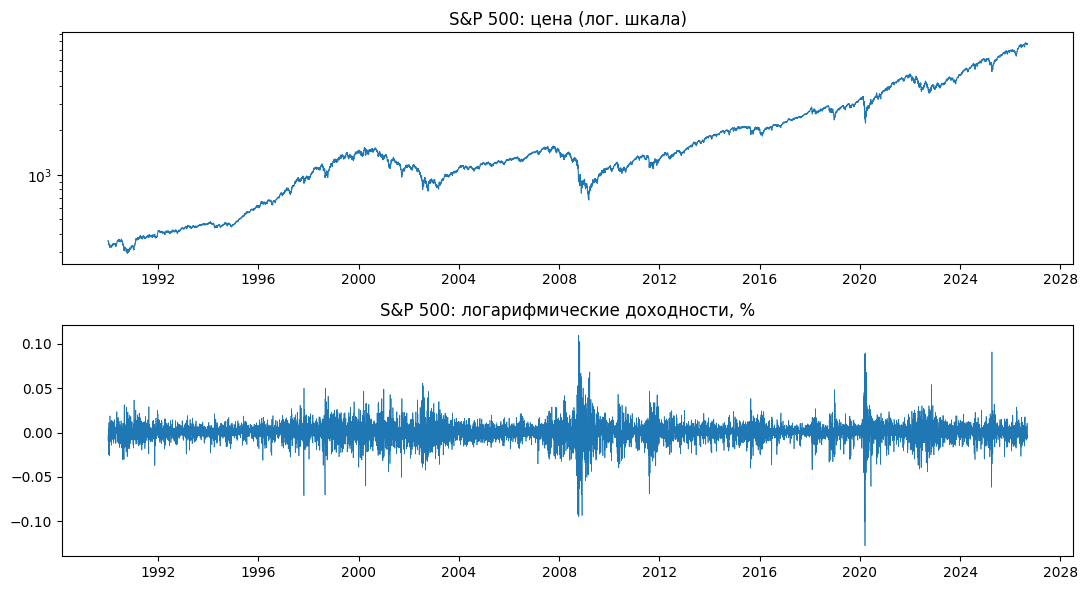

In [29]:
def plot_price_and_returns(prices, returns, name):
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
    axes[0].plot(prices.index, prices.values, linewidth=0.8)
    axes[0].set_yscale('log')
    axes[0].set_title(f'{name}: цена (лог. шкала)')

    axes[1].plot(returns.index, returns.values, linewidth=0.5)
    axes[1].set_title(f'{name}: логарифмические доходности, %')
    plt.tight_layout()
    plt.show()


plot_price_and_returns(sp500_prices, sp500_returns, 'S&P 500')

### 2.2 Описательная статистика и тест Жарка-Бера (Jarque-Bera)

In [30]:

def desc_stats(returns, name):
    jb_stat, jb_p = stats.jarque_bera(returns.values)
    return pd.Series({
        'N': len(returns), 'Среднее, %': (returns*100).mean(), 'Ст.откл., %': (returns*100).std(),
        'Мин, %': (returns*100).min(), 'Макс, %': (returns*100).max(),
        'Асимметрия': stats.skew(returns.values), 'Эксцесс (excess)': stats.kurtosis(returns.values),
        'Жарк-Бера stat': jb_stat, 'Жарк-Бера p-value': jb_p,
    }, name=name)


desc_sp500 = desc_stats(sp500_returns, 'S&P 500')
pd.DataFrame([desc_sp500]).round(4)

,N,"Среднее, %","Ст.откл., %","Мин, %","Макс, %",Асимметрия,Эксцесс (excess),Жарк-Бера stat,Жарк-Бера p-value
S&P 500,"9,238.000000",0.033100,1.133700,-12.765200,10.957200,-0.363800,10.876700,"45,740.416300",0.000000


Эксцесс (excess kurtosis) далеко за 0 (нормальное распределение имеет
excess kurtosis = 0), значит "толстые хвосты": экстремальные дневные движения случаются
намного чаще, чем предсказывает нормальное распределение. Тест Жарка-Бера отвергает
нормальность при p ≈ 0. Это и есть главный практический аргумент в пользу t-распределения
вместо нормального в GARCH-моделях ниже.



## 3. Стационарность: ADF, KPSS

Прежде чем моделировать дисперсию, нужно убедиться, что сам ряд доходностей стационарен.
Используем два теста с противоположными нулевыми гипотезами: если оба согласны, вывод
надёжнее.

- **ADF** (Augmented Dickey-Fuller): $H_0$ означает, что есть единичный корень (ряд нестационарен).
- **KPSS**: $H_0$ означает, что ряд стационарен.

In [32]:
def stationarity_tests(returns, name):
    adf_stat, adf_p, *_ = adfuller(returns.values, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(returns.values, regression='c', nlags='auto')
    return pd.Series({
        'ADF stat': adf_stat, 'ADF p-value': adf_p,
        'KPSS stat': kpss_stat, 'KPSS p-value': kpss_p,
    }, name=name)


stat_sp500 = stationarity_tests(sp500_returns, 'S&P 500')
pd.DataFrame([stat_sp500]).round(4)

/var/folders/41/qjxjzpf949v0cggfdy4klf300000gn/T/ipykernel_52152/544888393.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(returns.values, regression='c', nlags='auto')


,ADF stat,ADF p-value,KPSS stat,KPSS p-value
S&P 500,-17.594800,0.000000,0.117700,0.100000
